In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [3]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.shape)
    print(df.head())

Fund Master
(40, 15)
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  

In [10]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Merge with scheme names
nav_plot = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

import plotly.express as px

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)"
)

# Highlight Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.2,
    line_width=0,
    annotation_text="2023 Bull Run"
)

# Highlight Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="lightcoral",
    opacity=0.2,
    line_width=0,
    annotation_text="2024 Market Correction"
)

fig.show()


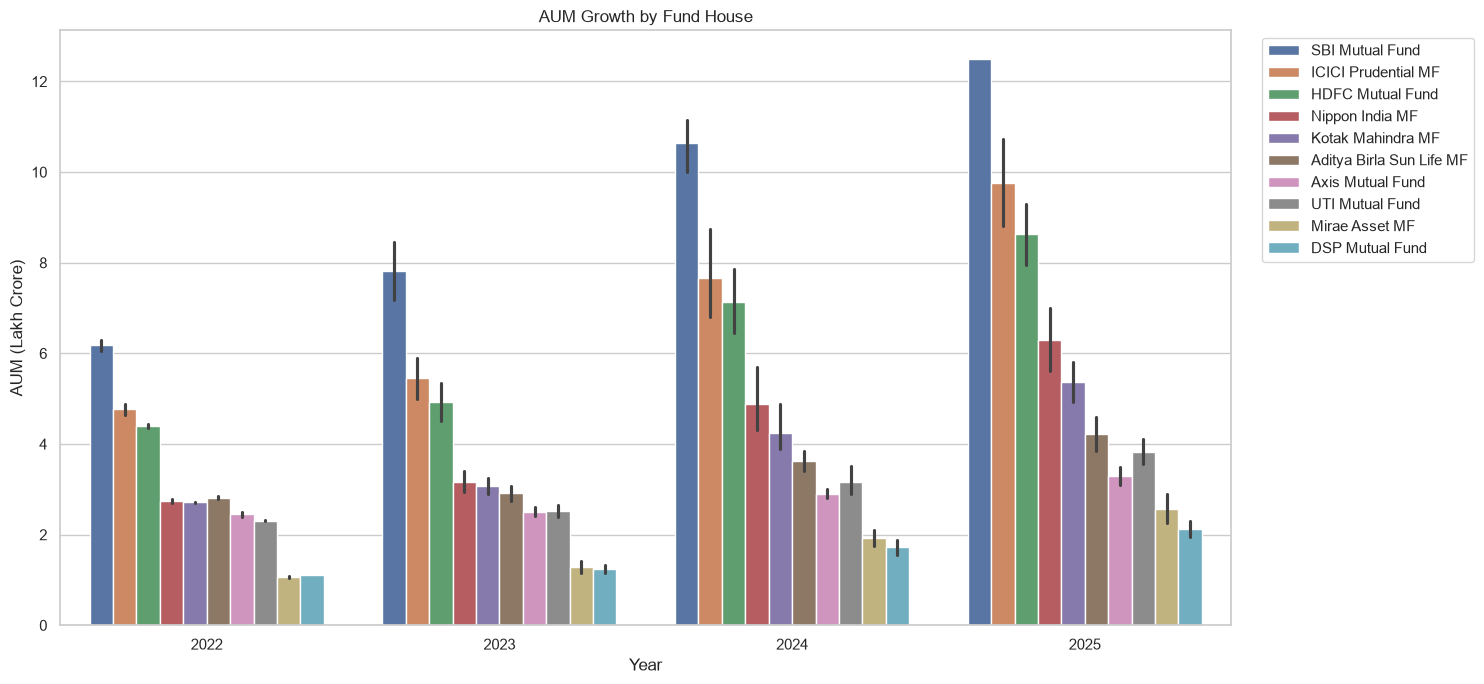

In [12]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(15,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02,1),loc="upper left")

plt.tight_layout()

plt.savefig("../reports/charts/aum_growth.png")

plt.show()

In [13]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend"
)

highest = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=highest["month"],
    y=highest["sip_inflow_crore"],
    text=f"Highest ₹{highest['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

fig.write_html("../reports/charts/sip_trend.html")

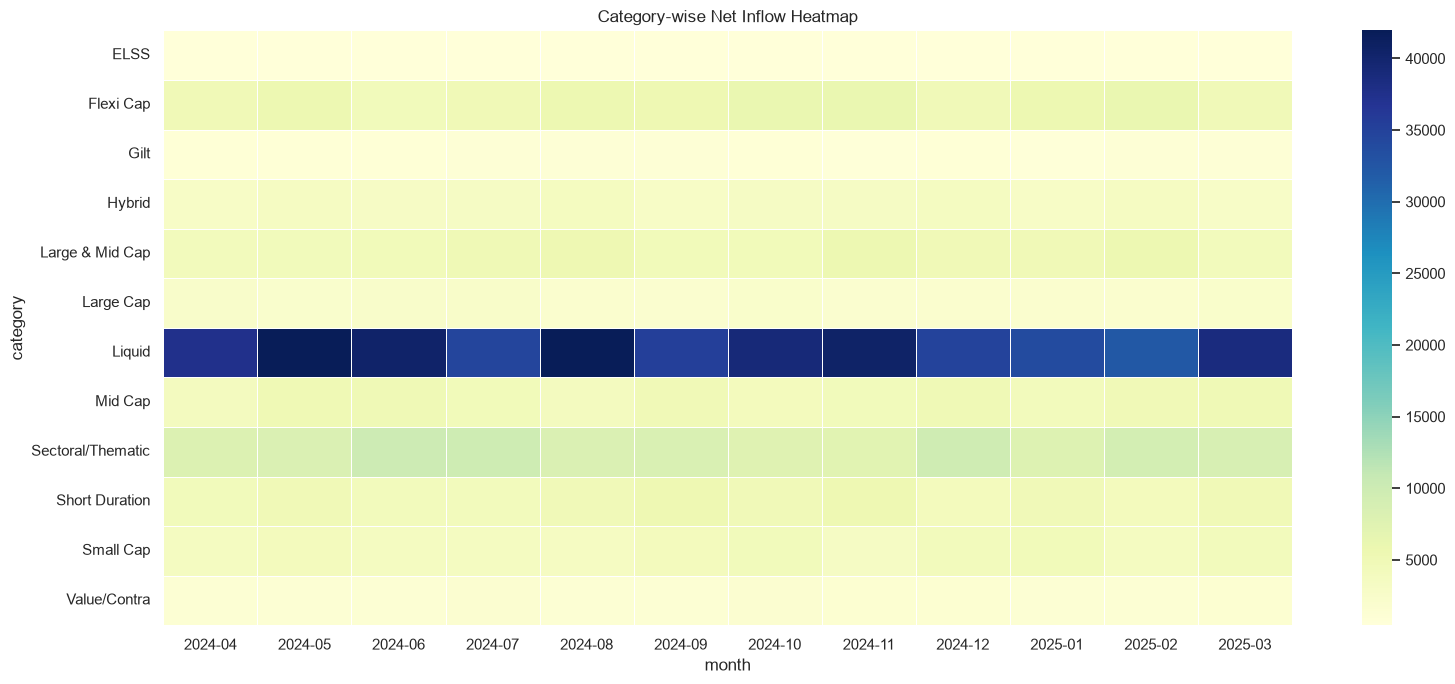

In [14]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,7))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")

plt.tight_layout()

plt.savefig("../reports/charts/category_heatmap.png")

plt.show()

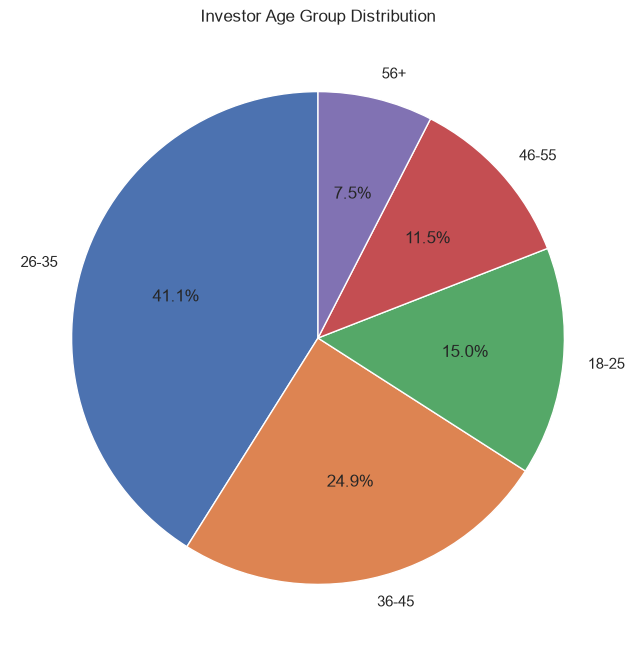

In [15]:
plt.figure(figsize=(8,8))

age_counts = transactions["age_group"].value_counts()

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig("../reports/charts/age_group_distribution.png")

plt.show()

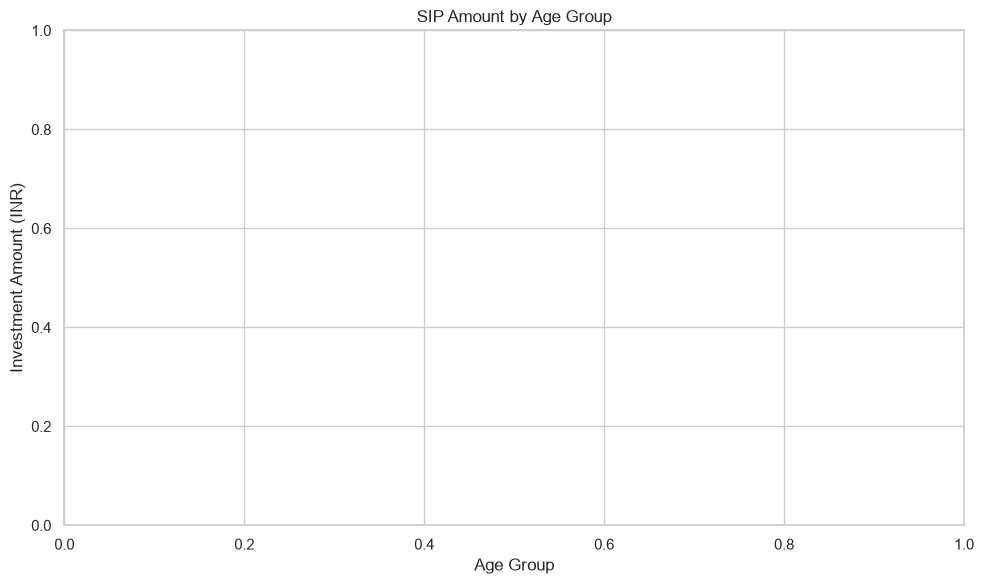

In [17]:
sip_data = transactions[
    transactions["transaction_type"] == "Sip"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_data,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.tight_layout()

plt.savefig("../reports/charts/sip_boxplot_age.png")

plt.show()

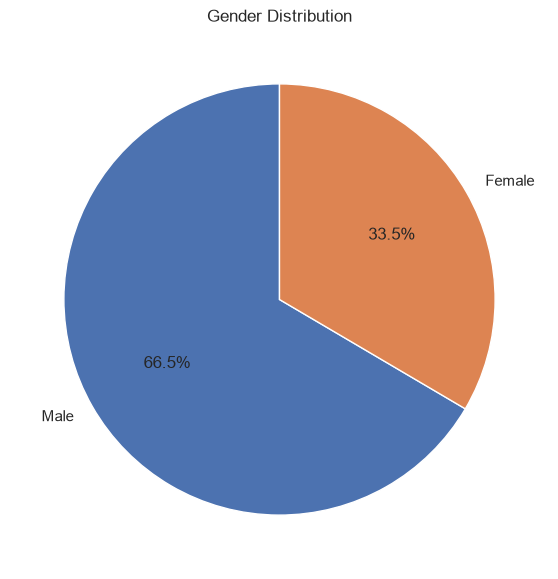

In [18]:
plt.figure(figsize=(7,7))

gender = transactions["gender"].value_counts()

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.savefig("../reports/charts/gender_distribution.png")

plt.show()

In [20]:
print(transactions["transaction_type"].unique())

<StringArray>
['SIP', 'Redemption', 'Lumpsum']
Length: 3, dtype: str


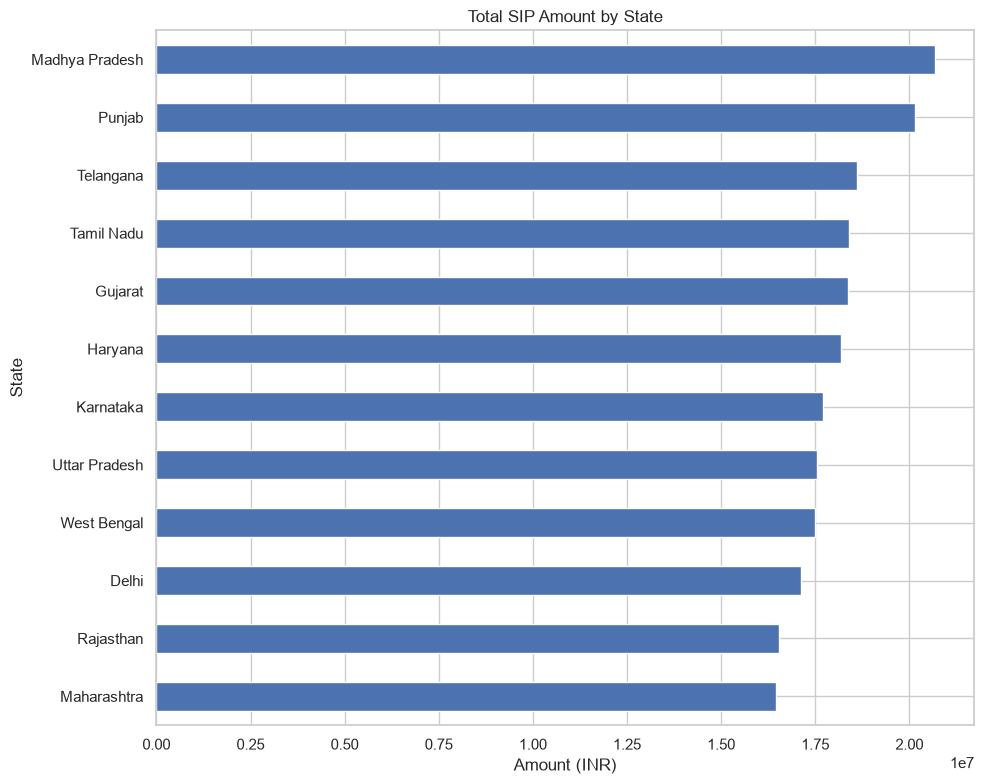

In [26]:
sip_data = transactions[
    transactions["transaction_type"] == "SIP"
]

state = (
    sip_data
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10,8))

state.plot(kind="barh")

plt.title("Total SIP Amount by State")
plt.xlabel("Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig("../reports/charts/state_distribution.png")

plt.show()

In [27]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


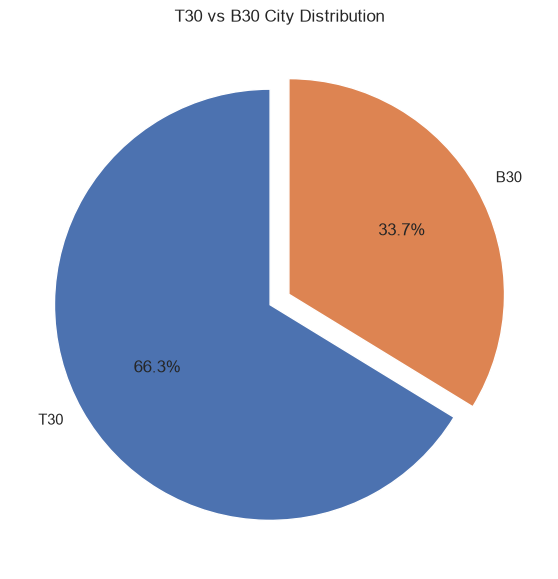

In [28]:
plt.figure(figsize=(7,7))

tier = transactions["city_tier"].value_counts()

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05]*len(tier)
)

plt.title("T30 vs B30 City Distribution")

plt.savefig("../reports/charts/city_tier_distribution.png")

plt.show()

In [29]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


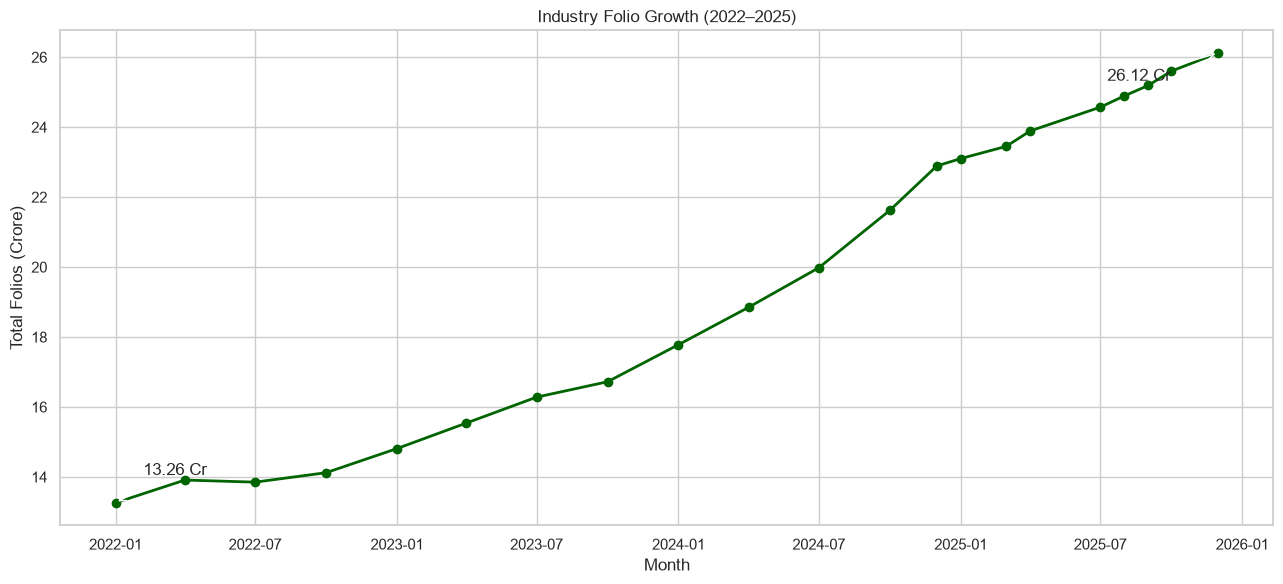

In [30]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(13,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2,
    color="darkgreen"
)

plt.title("Industry Folio Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.annotate(
    "13.26 Cr",
    xy=(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0]),
    xytext=(20,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "26.12 Cr",
    xy=(folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1]),
    xytext=(-80,-20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()

plt.savefig("../reports/charts/folio_growth.png")

plt.show()

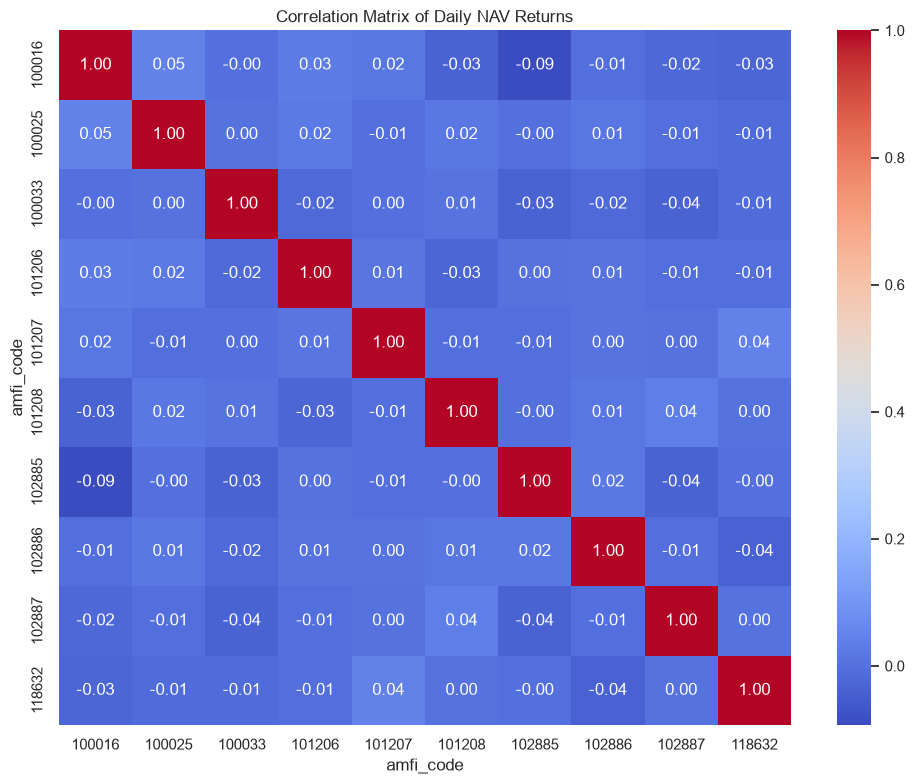

In [31]:
nav["date"] = pd.to_datetime(nav["date"])

pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change().dropna()

corr = returns.iloc[:, :10].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig("../reports/charts/nav_correlation.png")

plt.show()

In [32]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


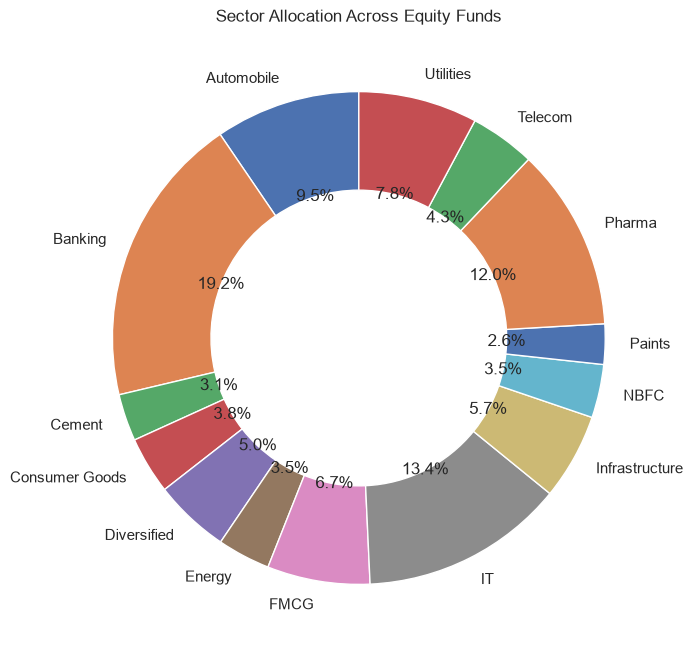

In [33]:
sector = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig("../reports/charts/sector_allocation.png")

plt.show()

In [34]:
print(transactions.columns.tolist())

print(folio.columns.tolist())

print(portfolio.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


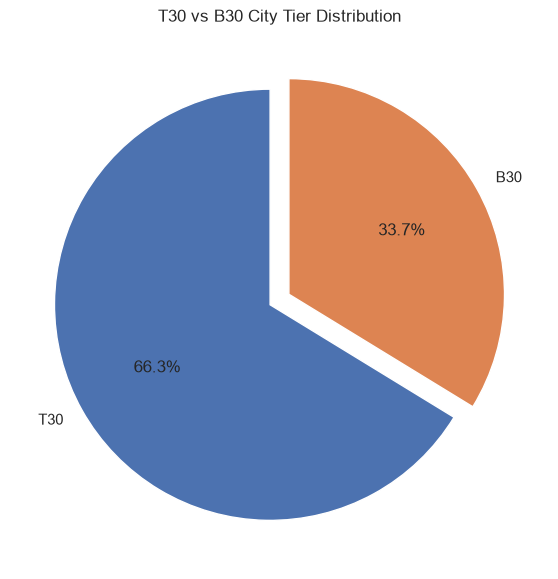

In [35]:
plt.figure(figsize=(7,7))

city_tier = transactions["city_tier"].value_counts()

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05] * len(city_tier)
)

plt.title("T30 vs B30 City Tier Distribution")

plt.savefig("../reports/charts/city_tier_distribution.png")

plt.show()

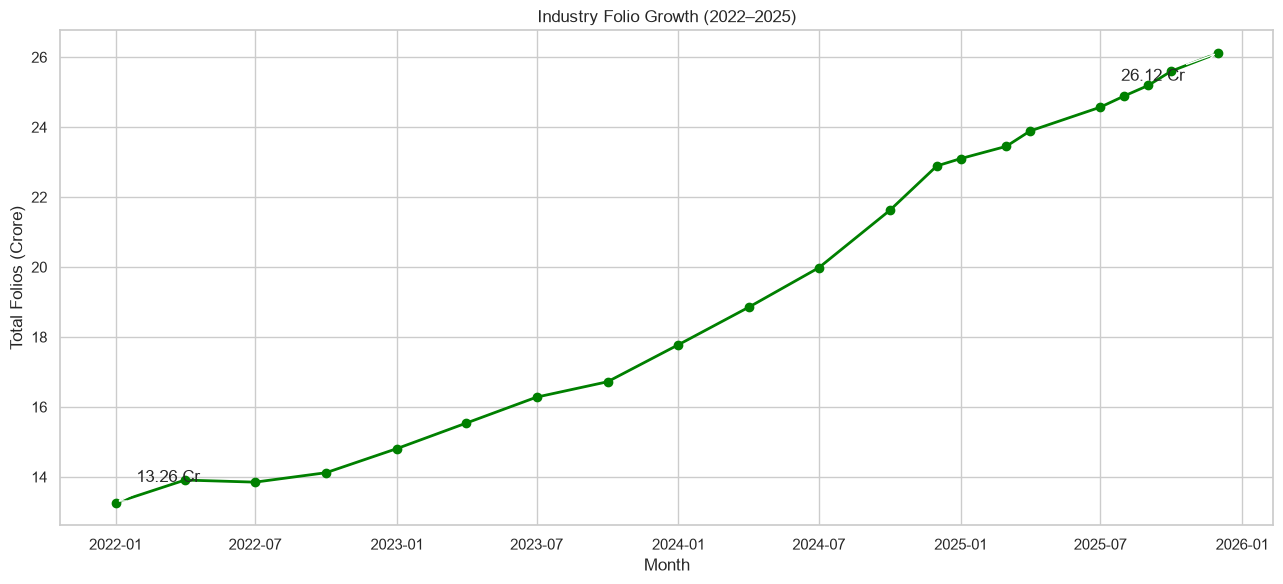

In [36]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(13,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Industry Folio Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.annotate(
    "13.26 Cr",
    xy=(folio.iloc[0]["month"], folio.iloc[0]["total_folios_crore"]),
    xytext=(15,15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "26.12 Cr",
    xy=(folio.iloc[-1]["month"], folio.iloc[-1]["total_folios_crore"]),
    xytext=(-70,-20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()

plt.savefig("../reports/charts/folio_growth.png")

plt.show()

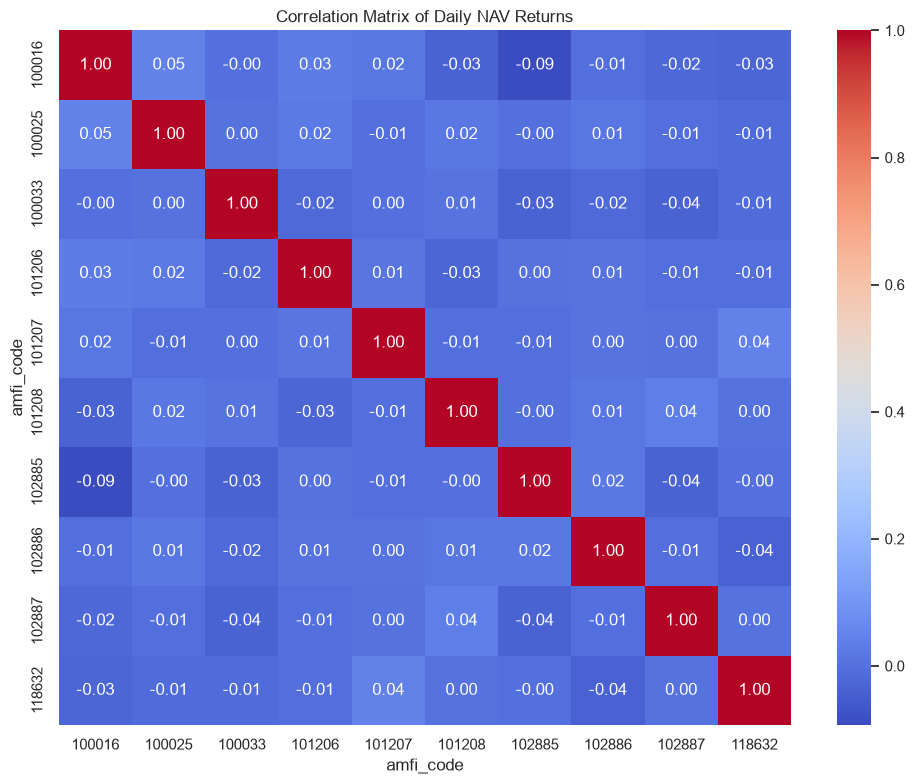

In [37]:
nav["date"] = pd.to_datetime(nav["date"])

pivot = nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

daily_returns = pivot.pct_change().dropna()

corr = daily_returns.iloc[:, :10].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig("../reports/charts/nav_correlation.png")

plt.show()

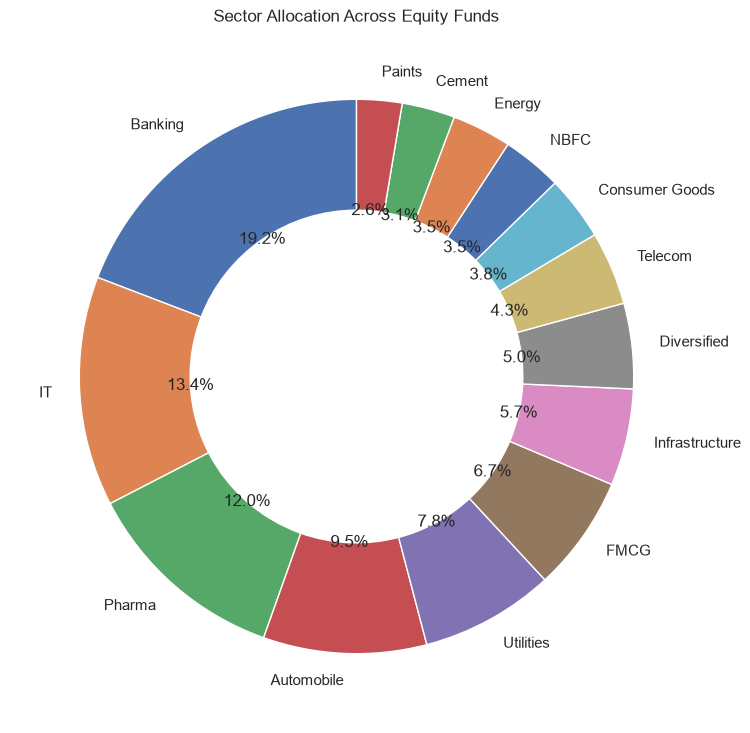

In [38]:
sector = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,9))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig("../reports/charts/sector_allocation.png")

plt.show()

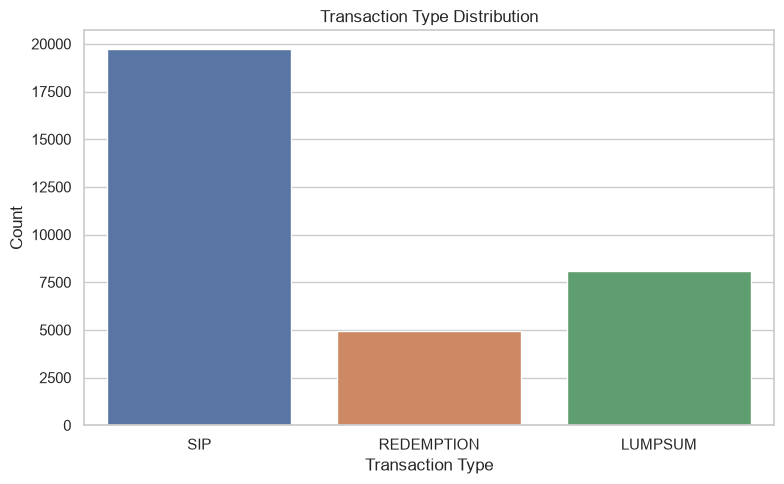

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x="transaction_type",
    hue="transaction_type",
    legend=False
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../reports/charts/transaction_type_distribution.png")

plt.show()

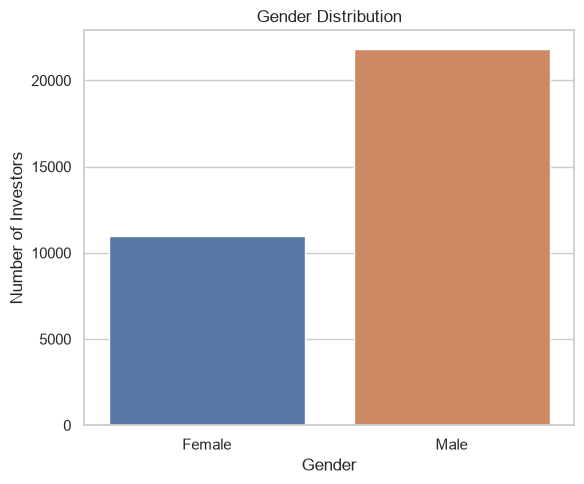

In [40]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=transactions,
    x="gender",
    hue="gender",
    legend=False
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.tight_layout()

plt.savefig("../reports/charts/gender_bar.png")

plt.show()

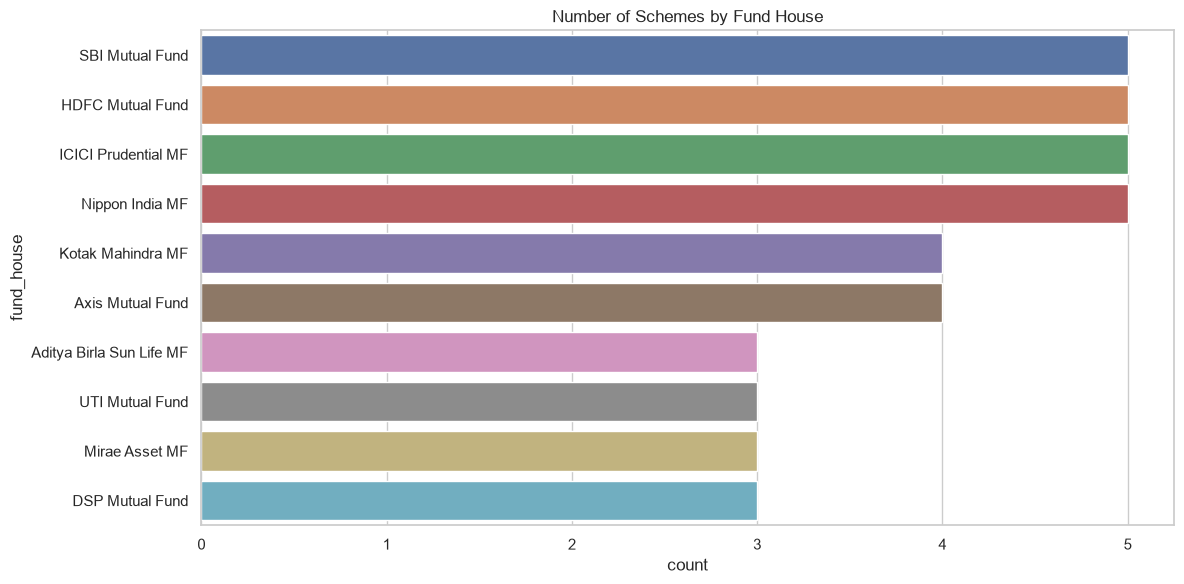

In [41]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=fund_master,
    y="fund_house",
    order=fund_master["fund_house"].value_counts().index,
    hue="fund_house",
    legend=False
)

plt.title("Number of Schemes by Fund House")

plt.tight_layout()

plt.savefig("../reports/charts/fund_house_distribution.png")

plt.show()

# Key EDA Findings

### 1
Daily NAV values showed an overall upward trend from 2022 to 2026, indicating long-term growth in mutual fund performance.

### 2
The strongest NAV growth was observed during the 2023 bull market period.

### 3
Monthly SIP inflows increased steadily, reaching the highest value in December 2025.

### 4
Large-cap and flexi-cap categories attracted consistently higher investments than several other fund categories.

### 5
The 26–35 age group contributed the highest number of investor transactions.

### 6
SIP was the most preferred transaction type among investors.

### 7
Investments were concentrated in major states such as Maharashtra, Karnataka, Tamil Nadu, and Telangana.

### 8
The mutual fund industry experienced continuous folio growth between 2022 and 2025.

### 9
Several mutual fund schemes exhibited strong positive daily NAV return correlations.

### 10
The Banking, IT, and Financial Services sectors accounted for a significant portion of portfolio allocations.